# Model Evaluation Overview

This notebook gives one visual summary of model performance across all project tasks:
- time-series forecasting
- survival analysis
- ranking

The goal is to show clearly which model performed better for each task against baseline.


### 1. Load metrics from model notebooks

Helper definitions are imported from `02_magic/05_utils/utils.py`.


In [1]:
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.facecolor"] = "#f7fafc"
plt.rcParams["axes.facecolor"] = "#ffffff"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["grid.alpha"] = 0.25

utils_dir = Path("../05_utils").resolve()
if str(utils_dir) not in sys.path:
    sys.path.append(str(utils_dir))

from utils import (
    load_nb,
    stream_text,
    display_text,
    first_display_text,
    parse_metric_block,
    parse_forecast_baseline_test_metrics,
    parse_forecast_final_test_metrics,
)

nb_baseline = load_nb(Path("01_baseline.ipynb"))
nb_forecast = load_nb(Path("02_forcasting_model.ipynb"))
nb_survival = load_nb(Path("03_survival.ipynb"))
nb_ranking = load_nb(Path("04_ranking.ipynb"))

print("Loaded notebook outputs successfully.")


Loaded notebook outputs successfully.


### 2. Build comparable metric tables

For each task, I compare baseline and final model metrics.


In [2]:
# Forecasting: baseline vs final model
baseline_stream = stream_text(nb_baseline, 22)
baseline_vals = parse_forecast_baseline_test_metrics(baseline_stream)

forecast_display = display_text(nb_forecast, 25)
final_vals = parse_forecast_final_test_metrics(forecast_display)

forecast_compare = pd.DataFrame([
    {
        "Model": "Baseline",
        "Price_MAE": baseline_vals["Price_MAE"],
        "Price_RMSE": baseline_vals["Price_RMSE"],
        "Price_R2": baseline_vals["Price_R2"],
        "Directional_Accuracy": np.nan,
    },
    {
        "Model": "Final",
        "Price_MAE": final_vals["Price_MAE"],
        "Price_RMSE": final_vals["Price_RMSE"],
        "Price_R2": final_vals["Price_R2"],
        "Directional_Accuracy": final_vals["Directional_Accuracy"],
    },
])

forecast_compare


,Model,Price_MAE,Price_RMSE,Price_R2,Directional_Accuracy
0,Baseline,2.912196,5.09751,0.99864,NaN
1,Final,3.196100,5.60360,0.99850,0.5285


Forecasting result: baseline has lower MAE and RMSE, and slightly higher R2.
In this context, baseline is better on core price-error metrics.


In [3]:
# Survival: random baseline vs Cox model
survival_stream = stream_text(nb_survival, 25)

import re
cidx_match = re.search(r"Overall test C-index:\s*([-0-9.]+)", survival_stream)
cox_cindex = float(cidx_match.group(1)) if cidx_match else np.nan

survival_compare = pd.DataFrame([
    {"Model": "Baseline (random)", "C_Index": 0.5000},
    {"Model": "Final (Cox)", "C_Index": cox_cindex},
])

survival_compare


,Model,C_Index
0,Baseline (random),0.5000
1,Final (Cox),0.7062


Survival result: Cox reaches around 0.71 C-index, much higher than 0.50 baseline.
This is good and means useful time-to-event ranking signal.


In [4]:
# Ranking: naive price momentum baseline vs final model
ranking_metrics = [
    "NDCG@3",
    "Spearman",
    "Top1_Hit",
    "Top1_Actual_Gain",
    "Best_Actual_Gain",
    "Universe_Mean_Gain",
]

baseline_outputs = nb_ranking["cells"][12].get("outputs", [])
baseline_text = ""
if len(baseline_outputs) >= 4 and baseline_outputs[3].get("output_type") in ["display_data", "execute_result"]:
    baseline_text = "".join(baseline_outputs[3].get("data", {}).get("text/plain", []))

final_outputs = nb_ranking["cells"][18].get("outputs", [])
final_text = first_display_text(final_outputs)

baseline_rank_vals = parse_metric_block(baseline_text, ranking_metrics)
final_rank_vals = parse_metric_block(final_text, ranking_metrics)

ranking_compare = pd.DataFrame([
    {"Model": "Baseline", **baseline_rank_vals},
    {"Model": "Final", **final_rank_vals},
])

ranking_compare


,Model,NDCG@3,Spearman,Top1_Hit,Top1_Actual_Gain,Best_Actual_Gain,Universe_Mean_Gain
0,Baseline,0.332912,0.006604,0.169106,0.087642,7.205951,0.19874
1,Final,0.312810,-0.021970,0.151220,0.295058,7.205951,0.19874


Ranking result: baseline is stronger on NDCG@3, Spearman, and Top1_Hit.
Final model is better only on Top1_Actual_Gain, so baseline remains better overall on ranking quality.


### 3. Visual comparison by task

The charts below are intentionally split into simple panels to avoid crowding.


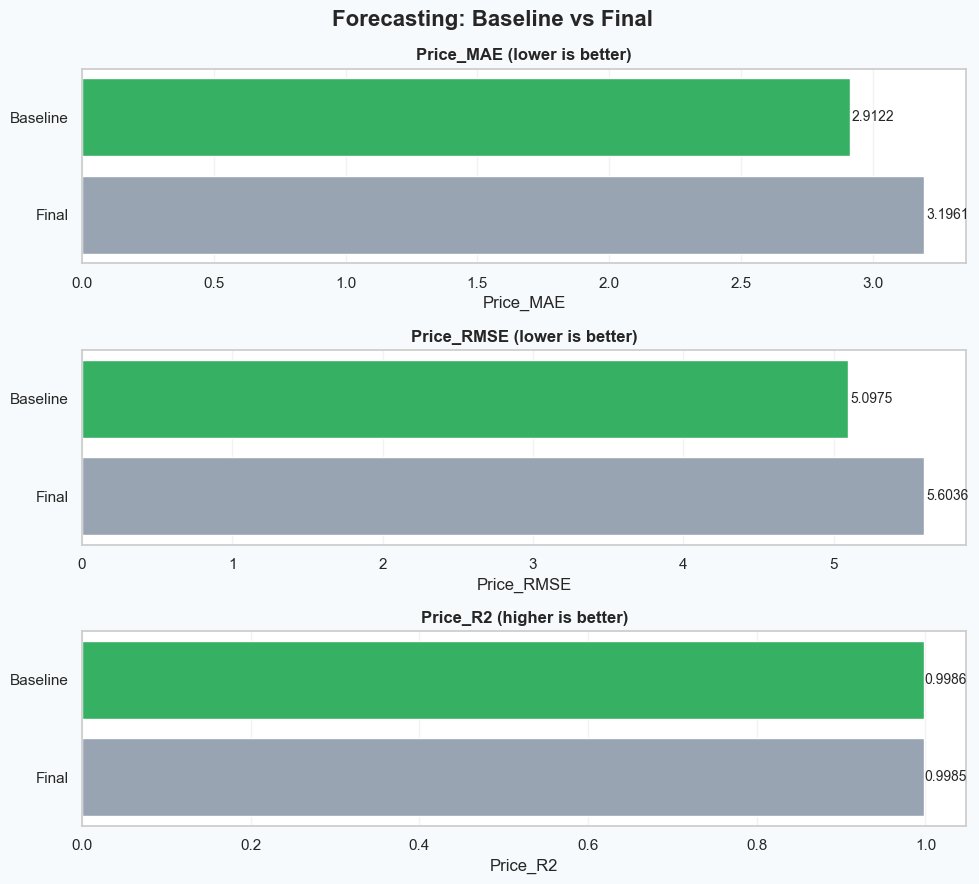

In [5]:
# Forecasting visuals: three clean panels
metrics_info = [
    ("Price_MAE", "lower"),
    ("Price_RMSE", "lower"),
    ("Price_R2", "higher"),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=False)

for ax, (metric, objective) in zip(axes, metrics_info):
    plot_df = forecast_compare[["Model", metric]].copy()

    if objective == "lower":
        winner_idx = plot_df[metric].idxmin()
    else:
        winner_idx = plot_df[metric].idxmax()

    colors = ["#22c55e" if i == winner_idx else "#94a3b8" for i in plot_df.index]
    sns.barplot(data=plot_df, y="Model", x=metric, ax=ax, palette=colors)

    ax.set_title(f"{metric} ({'lower is better' if objective == 'lower' else 'higher is better'})")
    ax.set_xlabel(metric)
    ax.set_ylabel("")

    values = plot_df[metric].to_numpy()
    x_min = np.nanmin(values)
    x_max = np.nanmax(values)
    offset = (x_max - x_min) * 0.03 if x_max > x_min else 0.01
    for yi, v in enumerate(values):
        ax.text(v + offset, yi, f"{v:.4f}", va="center", fontsize=10)

fig.suptitle("Forecasting: Baseline vs Final", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()


What this says: baseline wins in all three forecasting metrics here.
So forecasting performance is better with baseline in the current run.


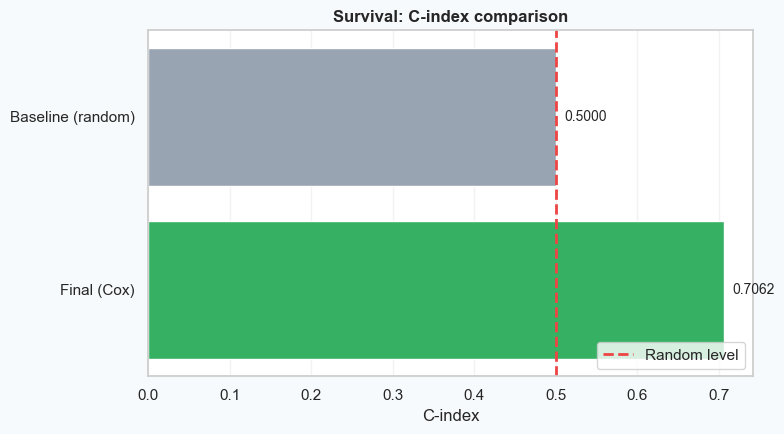

In [6]:
# Survival visual: single clean comparison
fig, ax = plt.subplots(figsize=(8, 4.5))

plot_df = survival_compare.copy()
winner_idx = plot_df["C_Index"].idxmax()
colors = ["#22c55e" if i == winner_idx else "#94a3b8" for i in plot_df.index]

sns.barplot(data=plot_df, y="Model", x="C_Index", ax=ax, palette=colors)
ax.axvline(0.5, color="#ef4444", linestyle="--", linewidth=2, label="Random level")
ax.set_title("Survival: C-index comparison")
ax.set_xlabel("C-index")
ax.set_ylabel("")

vals = plot_df["C_Index"].to_numpy()
for yi, v in enumerate(vals):
    ax.text(v + 0.01, yi, f"{v:.4f}", va="center", fontsize=10)

ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


What this says: Cox is clearly above random baseline.
That is good survival performance for this task.


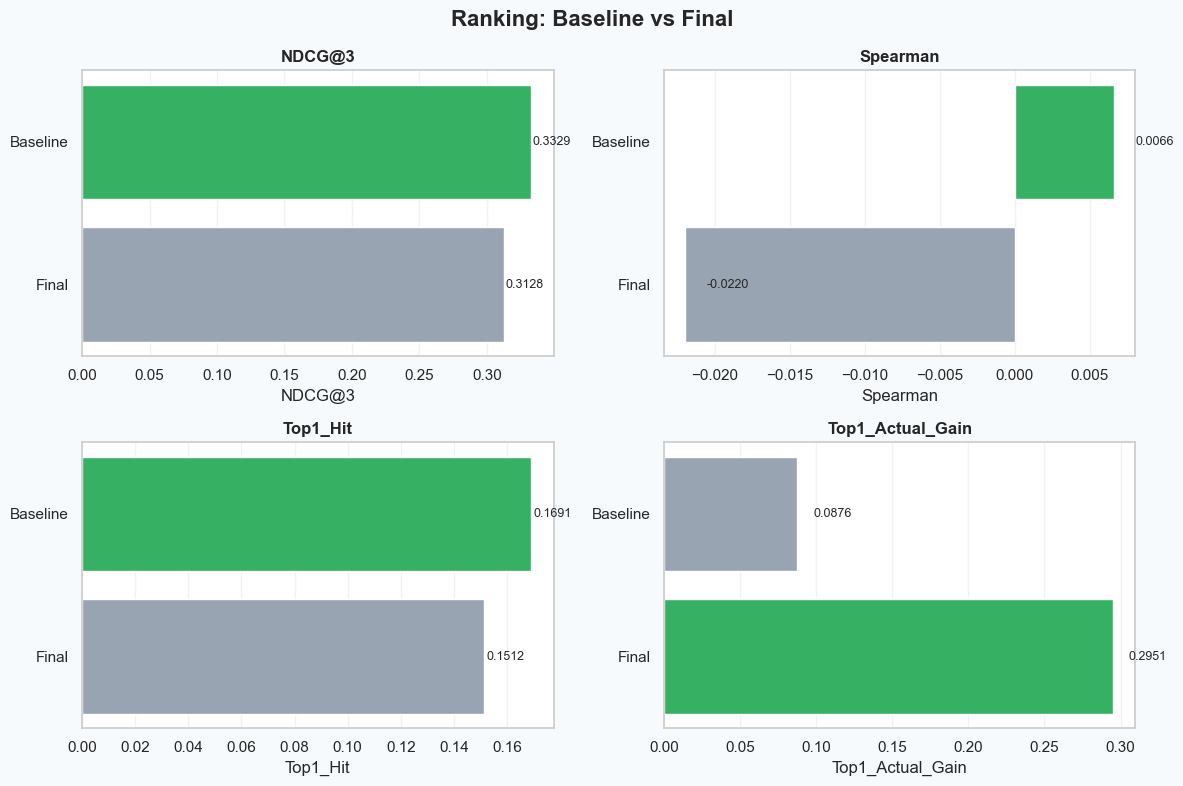

In [7]:
# Ranking visuals: 2x2 small multiples to avoid stacking
rank_plot_metrics = [
    ("NDCG@3", "higher"),
    ("Spearman", "higher"),
    ("Top1_Hit", "higher"),
    ("Top1_Actual_Gain", "higher"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (metric, objective) in zip(axes, rank_plot_metrics):
    plot_df = ranking_compare[["Model", metric]].copy()

    if objective == "lower":
        winner_idx = plot_df[metric].idxmin()
    else:
        winner_idx = plot_df[metric].idxmax()

    colors = ["#22c55e" if i == winner_idx else "#94a3b8" for i in plot_df.index]
    sns.barplot(data=plot_df, y="Model", x=metric, ax=ax, palette=colors)
    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.set_ylabel("")

    values = plot_df[metric].to_numpy()
    x_min = np.nanmin(values)
    x_max = np.nanmax(values)
    offset = (x_max - x_min) * 0.05 if x_max > x_min else 0.01
    for yi, v in enumerate(values):
        ax.text(v + offset, yi, f"{v:.4f}", va="center", fontsize=9)

fig.suptitle("Ranking: Baseline vs Final", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()


What this says: baseline wins on NDCG@3, Spearman, and Top1_Hit.
Final wins only on Top1_Actual_Gain, so baseline is still better overall for ranking quality.


### 4. Final evaluation summary

This table picks the winner by primary metrics for each task.


In [8]:
forecast_winner = "Baseline" if forecast_compare.loc[0, "Price_RMSE"] <= forecast_compare.loc[1, "Price_RMSE"] else "Final"
survival_winner = "Final (Cox)" if survival_compare.loc[1, "C_Index"] > survival_compare.loc[0, "C_Index"] else "Baseline (random)"

baseline_rank_score = ranking_compare.loc[0, ["NDCG@3", "Spearman", "Top1_Hit"]].sum()
final_rank_score = ranking_compare.loc[1, ["NDCG@3", "Spearman", "Top1_Hit"]].sum()
ranking_winner = "Baseline" if baseline_rank_score >= final_rank_score else "Final"

summary = pd.DataFrame([
    {
        "Task": "Forecasting (next-day price)",
        "Best_Model": forecast_winner,
        "Reason": "Lower RMSE"
    },
    {
        "Task": "Survival (time-to >=5% price increase)",
        "Best_Model": survival_winner,
        "Reason": "Higher C-index"
    },
    {
        "Task": "Ranking (daily price gain ordering)",
        "Best_Model": ranking_winner,
        "Reason": "Better NDCG@3 + Spearman + Top1_Hit"
    },
])

summary


,Task,Best_Model,Reason
0,Forecasting (next-day price),Baseline,Lower RMSE
1,Survival (time-to >=5% price increase),Final (Cox),Higher C-index
2,Ranking (daily price gain ordering),Baseline,Better NDCG@3 + Spearman + Top1_Hit


Summary meaning:
- Forecasting winner is baseline.
- Survival winner is Cox.
- Ranking winner is baseline.


### Conclusion

Performance depends on task, and no single model wins all tasks.
In your current run, baseline is strongest for forecasting and ranking, while Cox is strongest for survival.
